# **Climatology Threshold**

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)



<xarray.DataArray 'capacity_factor' (quantile: 1)> Size: 8B
array([-0.03520854])
Coordinates:
  * quantile  (quantile) float64 8B 0.1


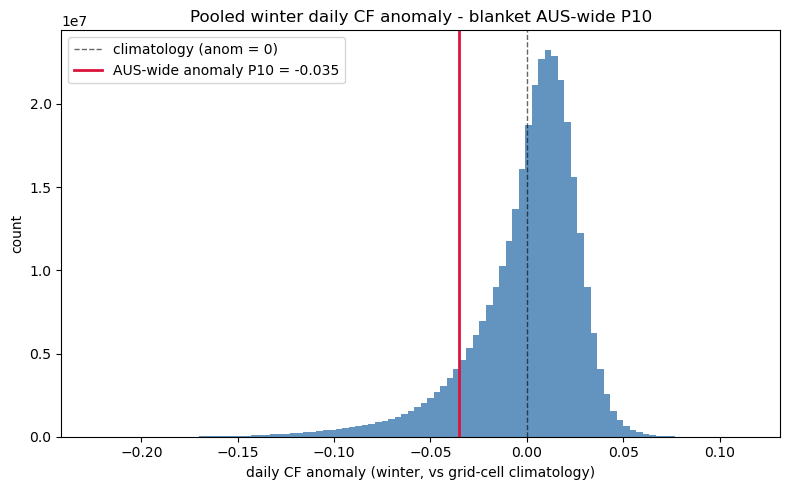

anom mean/median: 3.2426686402686755e-07 0.005801022052764893
anom min/max: -0.22457055747509003 0.11440734565258026
frac below P10 (≈0.10 by construction): 0.09999993231622548
frac NaN: 0.0
raw winter CF min/max: 0.002685729181393981 0.313721239566803


In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar

solar_cf_path = "/home/563/ft3359/GC26-combined-solar-wind/data/raw/solar_cf"
var = 'capacity_factor'

ds = xr.open_mfdataset(f"{solar_cf_path}/*.nc", chunks={'time': 24*30})
cf = ds[var]

# hourly -> daily mean
cf_daily = cf.resample(time='1D').mean()
# Winter months: May - September
winter = cf_daily.sel(time=cf_daily.time.dt.month.isin([5, 6, 7, 8, 9]))
with ProgressBar():
    winter = winter.load()

# climatology: per-grid-cell day-of-year mean

clim = winter.groupby('time.dayofyear').mean('time')

# anomaly: daily CF minus its own grid-cell day-of-year climatology

winter_anom = winter.groupby('time.dayofyear') - clim

QUANTILES = [0.10]

thr_aus = winter_anom.quantile(QUANTILES)
print(thr_aus)
p10 = float(thr_aus.sel(quantile=0.10))

vals = winter_anom.values.ravel()
vals = vals[~np.isnan(vals)]
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, bins=100, color='steelblue', alpha=0.85)
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.6, label='climatology (anom = 0)')
ax.axvline(p10, color='crimson', lw=2, label=f'AUS-wide anomaly P10 = {p10:.3f}')
ax.set_xlabel('daily CF anomaly (winter, vs grid-cell climatology)')
ax.set_ylabel('count')
ax.set_title('Pooled winter daily CF anomaly - blanket AUS-wide P10')
ax.legend()
plt.tight_layout()
plt.show()

# diagnostics
print('anom mean/median:', float(winter_anom.mean()), float(winter_anom.median()))
print('anom min/max:', float(winter_anom.min()), float(winter_anom.max()))
print('frac below P10 (≈0.10 by construction):', float((winter_anom < p10).mean()))
print('frac NaN:', float(winter_anom.isnull().mean()))
print('raw winter CF min/max:', float(winter.min()), float(winter.max()))

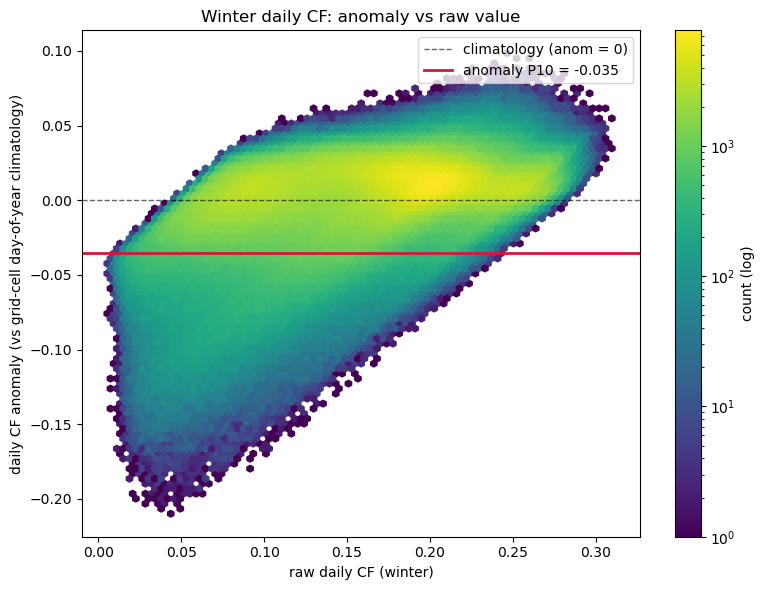

In [4]:
# anomaly vs raw winter CF
raw_full  = winter.values.ravel()
anom_full = winter_anom.values.ravel()

N_MAX = 3_000_000
rng = np.random.default_rng(0)
idx = rng.choice(raw_full.size, min(N_MAX, raw_full.size), replace=False)
raw  = raw_full[idx].astype(np.float32)
anom = anom_full[idx].astype(np.float32)
del raw_full, anom_full

m = np.isfinite(raw) & np.isfinite(anom)
raw, anom = raw[m], anom[m]

fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(raw, anom, gridsize=80, mincnt=1, cmap='viridis', bins='log')
ax.axhline(0, color='k', lw=1, ls='--', alpha=0.6, label='climatology (anom = 0)')
ax.axhline(p10, color='crimson', lw=2, label=f'anomaly P10 = {p10:.3f}')
ax.set_xlabel('raw daily CF (winter)')
ax.set_ylabel('daily CF anomaly (vs grid-cell day-of-year climatology)')
ax.set_title('Winter daily CF: anomaly vs raw value')
fig.colorbar(hb, ax=ax, label='count (log)')
ax.legend()
plt.tight_layout()
plt.show()